# VEDB Two-Layer Simulation — Diffusion Lengths and 2D Confidence Region

This notebook demonstrates diffusion-length fitting for a **two-layer sample**: a thin surface-damaged layer over a semi-infinite bulk. Both diffusion lengths — L₀ (damaged layer) and L₁ (bulk) — are fitted simultaneously and their joint confidence region is visualised as a 2D χ² map.

## Physical scenario

Ion implantation or irradiation creates a near-surface damaged layer (thickness ~200 nm) with a short diffusion length (L₀ ~ 50 nm) due to vacancy-type defects. Below this, the undamaged bulk has a longer diffusion length (L₁ ~ 150 nm). The S parameter decreases monotonically with beam energy as positrons penetrate from the surface-sensitive to the bulk-sensitive regime.


## 2D confidence region

For two free parameters the Δχ² thresholds are those of the χ² distribution with 2 DOF:

| Confidence level | Δχ² threshold |
|---|---|
| 68.3 % | 2.30 |
| 95.0 % | 5.99 |
| 99.0 % | 9.21 |

The positive correlation between L₀ and L₁ visible in the tilted confidence ellipse is physically meaningful: overestimating L₀ (more diffusion in the surface layer) can be partially compensated by overestimating L₁ (more diffusion in the bulk).

## Workflow

1. Define the ground-truth two-layer Cu sample
2. Simulate S(E) over 0.5–29.5 keV and add noise
3. Fit L₀ and L₁ simultaneously and compare to truth
4. Scan the 2D χ² grid and plot the confidence region

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from uncertainties.unumpy import uarray, nominal_values, std_devs
from pyPAS.transport import (
    makhov_material_parameters, makhov_profile,
    multilayer_implantation_profile, profile_solver,
)
from pyPAS.model import Material, Layer, Sample
from pyPAS.analysis import DiffusionLengthOptimization, compute_annihilation_fractions

## 1. Ground-truth two-layer sample

Layer 0 represents the surface-damaged region (e.g. after ion implantation or irradiation); layer 1 is the undamaged bulk substrate. Both layers are Cu with normalised diffusion coefficients (D = 1).

> **Adapt** layer widths, diffusion lengths, and S values to your material system.

In [2]:
# ── Ground-truth parameters ───────────────────────────────────────────────────
L0_true  =  50.0   # surface-layer diffusion length [nm]
L1_true  = 150.0   # bulk diffusion length [nm]
w0       = 200     # surface layer width [nm]
D        =   1.0   # normalised diffusion coefficient (only L = sqrt(D/λ) matters)
S_surface = 0.540  # S at the surface channel
S_layer_0 = 0.525  # S in the damaged surface layer
S_layer_1 = 0.500  # S in the bulk
sigma_S   = 0.001  # measurement noise per energy point
# ─────────────────────────────────────────────────────────────────────────────

layer_0   = Layer(width=w0,     material=Material(diffusion=D, mobility=0,
                                                   bulk_annihilation_rate=D/L0_true**2))
layer_1   = Layer(width=10_000, material=Material(diffusion=D, mobility=0,
                                                   bulk_annihilation_rate=D/L1_true**2))
cu_sample = Sample(layers=[layer_0, layer_1], absorption_length=1.0)

Cu_params = makhov_material_parameters().iloc[9].copy()
Cu_params['density'] = 8.96   # g/cm³

print(f'Layer 0: width = {w0} nm,  L₀ = {L0_true} nm')
print(f'Layer 1: width = 10000 nm, L₁ = {L1_true} nm')

Layer 0: width = 200 nm,  L₀ = 50.0 nm
Layer 1: width = 10000 nm, L₁ = 150.0 nm


## 2. Simulate S(E)

Makhov implantation profiles are computed for each beam energy, the transport equation is solved, and annihilation fractions per channel (surface, layer 0, layer 1) are obtained. The noiseless S(E) is a linear combination weighted by those fractions; Gaussian noise mimics counting statistics.

In [3]:
# Beam energies: fine steps at low energy, 1 keV steps up to 29.5 keV
energies = np.arange(0.5, 30.0, 1.0)   # [keV], 29 points
depth    = np.linspace(0, cu_sample.sample_length(), 20_000)  # [nm]

implantation_profiles = [
    multilayer_implantation_profile(
        positron_energy=e, depth_vector=depth,
        widths=[w0, 10_000],
        materials_parameters=[Cu_params, Cu_params],
        densities=[Cu_params['density'], Cu_params['density']],
        implantation_profile_function=makhov_profile,
    )
    for e in energies
]

# Solve transport and compute annihilation fractions — shape (n_energies, 3)
# columns: [surface, layer_0, layer_1]
solved_profiles = [profile_solver(p, cu_sample) for p in implantation_profiles]
frac_matrix = np.array([
    compute_annihilation_fractions(p, cu_sample).values
    for p in solved_profiles
])

s_per_channel_true = np.array([S_surface, S_layer_0, S_layer_1])
s_noiseless        = frac_matrix @ s_per_channel_true

rng     = np.random.default_rng(seed=42)
s_noisy = s_noiseless + rng.normal(0, sigma_S, len(energies))

s_measurement = pd.Series(
    uarray(s_noisy, np.full(len(energies), sigma_S)),
    index=energies, name='S',
)
s_measurement.index.name = 'energy'

print(f'E = {energies[0]:.1f} keV:  fracs = {frac_matrix[0].round(3)}')
print(f'E = {energies[-1]:.1f} keV:  fracs = {frac_matrix[-1].round(3)}')
print(f'S range: {s_noiseless.min():.4f} – {s_noiseless.max():.4f}')

E = 0.5 keV:  fracs = [0.956 0.044 0.   ]
E = 29.5 keV:  fracs = [0.011 0.116 0.873]
S range: 0.5033 – 0.5393


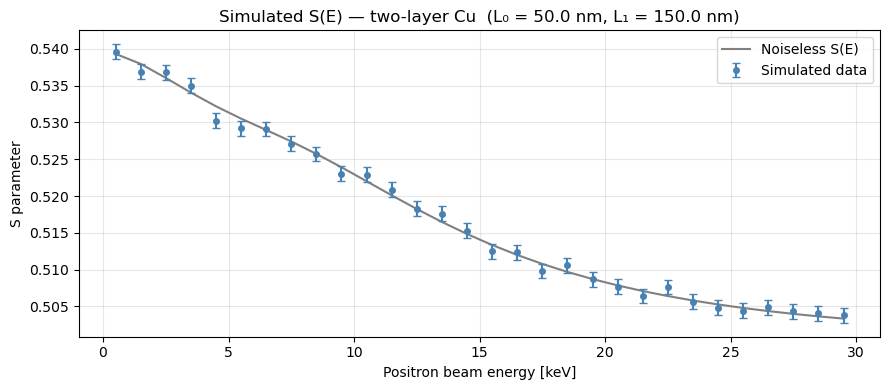

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(energies, s_noiseless, '-', color='gray', lw=1.5, label='Noiseless S(E)')
ax.errorbar(energies, nominal_values(s_measurement.values),
            yerr=std_devs(s_measurement.values),
            fmt='o', capsize=3, color='steelblue', markersize=4, label='Simulated data')
ax.set_xlabel('Positron beam energy [keV]')
ax.set_ylabel('S parameter')
ax.set_title(f'Simulated S(E) — two-layer Cu  (L₀ = {L0_true} nm, L₁ = {L1_true} nm)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Fit both diffusion lengths

The optimizer starts from an initial guess that is deliberately offset from the truth for both parameters. The covariance matrix gives marginal uncertainties and the off-diagonal correlation coefficient.

In [5]:
# Initial guess — offset from truth
L0_init, L1_init = 80.0, 100.0

init_layer_0 = Layer(width=w0,     material=Material(diffusion=D, mobility=0,
                                                       bulk_annihilation_rate=D/L0_init**2))
init_layer_1 = Layer(width=10_000, material=Material(diffusion=D, mobility=0,
                                                       bulk_annihilation_rate=D/L1_init**2))
initial_sample = Sample(layers=[init_layer_0, init_layer_1], absorption_length=1.0)

vedbfit = DiffusionLengthOptimization(
    positron_implantation_profiles=implantation_profiles,
    s_measurement=s_measurement,
    initial_guess=initial_sample,
    num_of_mesh_cells=10_000,
)

In [6]:
# ── This cell typically takes 1–2 minutes ─────────────────────────────────────
best_fit, cov = vedbfit.optimize_diffusion_length(bounds=(0, 1000))
# ─────────────────────────────────────────────────────────────────────────────

L0_fit, L1_fit = best_fit
errs = np.sqrt(np.diag(cov))
corr = cov[0, 1] / (errs[0] * errs[1])

print(f'L₀:  true = {L0_true:.1f} nm   fit = {L0_fit:.1f} ± {errs[0]:.1f} nm')
print(f'L₁:  true = {L1_true:.1f} nm   fit = {L1_fit:.1f} ± {errs[1]:.1f} nm')
print(f'Correlation ρ(L₀, L₁) = {corr:.3f}')

L₀:  true = 50.0 nm   fit = 39.3 ± 10.6 nm
L₁:  true = 150.0 nm   fit = 140.1 ± 37.1 nm
Correlation ρ(L₀, L₁) = 0.752


S per channel:
  S_surface: fit = 0.5405   true = 0.5400
  S_layer_0: fit = 0.5253   true = 0.5250
  S_bulk: fit = 0.5002   true = 0.5000


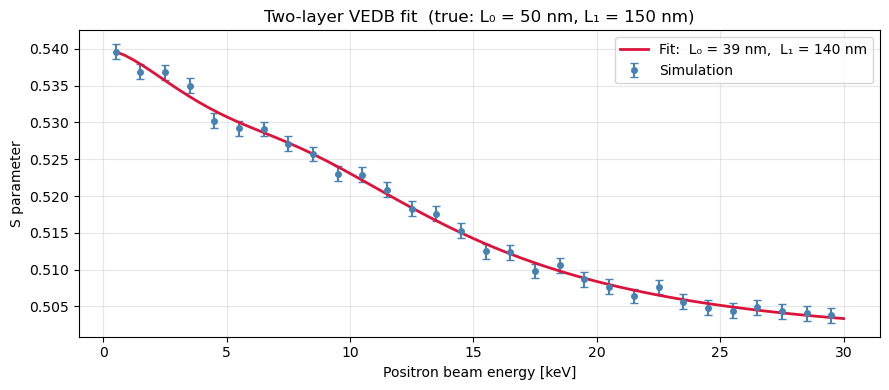

In [7]:
# S per annihilation channel at the best-fit parameters
sample_fit    = vedbfit.make_sample(best_fit)
frac_fit      = vedbfit.layers_transport_solver(sample_fit, implantation_profiles)
s_per_channel = vedbfit.layer_s_value(frac_fit)

print('S per channel:')
labels = ['S_surface', 'S_layer_0', 'S_bulk']
for lab, fit_val, true_val in zip(labels, s_per_channel, s_per_channel_true):
    print(f'  {lab}: fit = {fit_val:.4f}   true = {true_val:.4f}')

# Dense fit curve
e_dense = np.linspace(0.5, 30, 80)
profs_dense = [multilayer_implantation_profile(e, depth, [w0, 10_000],
               [Cu_params]*2, [Cu_params['density']]*2, makhov_profile) for e in e_dense]
frac_dense = vedbfit.layers_transport_solver(sample_fit, profs_dense)
s_fit_curve = frac_dense @ s_per_channel

fig, ax = plt.subplots(figsize=(9, 4))
ax.errorbar(energies, nominal_values(s_measurement.values),
            yerr=std_devs(s_measurement.values),
            fmt='o', capsize=3, color='steelblue', markersize=4, label='Simulation')
ax.plot(e_dense, s_fit_curve, '-', color='crimson', lw=2,
        label=f'Fit:  L₀ = {L0_fit:.0f} nm,  L₁ = {L1_fit:.0f} nm')
ax.set_xlabel('Positron beam energy [keV]')
ax.set_ylabel('S parameter')
ax.set_title(f'Two-layer VEDB fit  (true: L₀ = {L0_true:.0f} nm, L₁ = {L1_true:.0f} nm)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. 2D χ² confidence region

The joint confidence region for (L₀, L₁) is computed by scanning a grid and evaluating Δχ² = χ²(L₀, L₁) − χ²_min at each point. The contours enclose regions where the data are consistent with those parameter values at the stated confidence level.

The **tilted ellipse** reflects the positive correlation between L₀ and L₁: overestimating L₀ (stronger surface-layer trapping) can be partially compensated by overestimating L₁ (stronger bulk trapping), producing similar S(E) curves.

In [8]:
# ── 2D χ² grid scan — typically takes 2–3 minutes ────────────────────────────
L0_grid = np.arange(15,  91, 5, dtype=float)   # [nm]
L1_grid = np.arange(70, 251, 10, dtype=float)  # [nm]

chi2_map = np.full((len(L0_grid), len(L1_grid)), np.nan)
for i, L0 in enumerate(L0_grid):
    for j, L1 in enumerate(L1_grid):
        res = vedbfit.residuals(np.array([L0, L1]))
        if not np.any(np.abs(res) > 1e5):
            chi2_map[i, j] = float(np.sum(res**2))
# ─────────────────────────────────────────────────────────────────────────────

delta_chi2 = chi2_map - np.nanmin(chi2_map)
print(f'χ² scan complete.  min at '
      f'L₀ = {L0_grid[np.unravel_index(np.nanargmin(chi2_map), chi2_map.shape)[0]]:.0f} nm, '
      f'L₁ = {L1_grid[np.unravel_index(np.nanargmin(chi2_map), chi2_map.shape)[1]]:.0f} nm')

χ² scan complete.  min at L₀ = 40 nm, L₁ = 140 nm


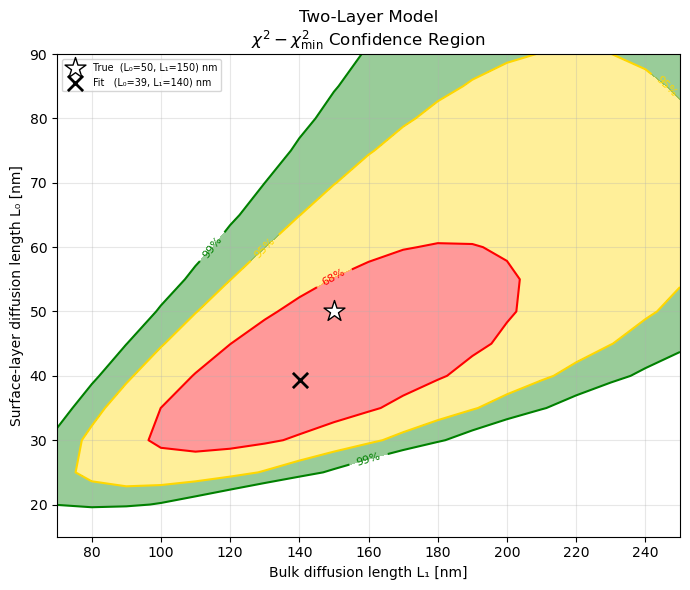

In [9]:
# 2-DOF chi-squared thresholds
THRESH_68, THRESH_95, THRESH_99 = 2.30, 5.99, 9.21

L1_mesh, L0_mesh = np.meshgrid(L1_grid, L0_grid)

fig, ax = plt.subplots(figsize=(7, 6))

# Filled confidence regions (outermost first so inner regions overlay)
ax.contourf(L1_mesh, L0_mesh, delta_chi2,
            levels=[0, THRESH_68, THRESH_95, THRESH_99],
            colors=['red', 'gold', 'green'], alpha=0.4)

# Black contour lines at the CI thresholds
cs = ax.contour(L1_mesh, L0_mesh, delta_chi2,
                levels=[THRESH_68, THRESH_95, THRESH_99],
                colors=['red', 'gold', 'green'], linewidths=1.5)
ax.clabel(cs, fmt={THRESH_68: '68%', THRESH_95: '95%', THRESH_99: '99%'},
          fontsize=8, inline=True)

# True and best-fit parameter points
ax.scatter([L1_true], [L0_true], marker='*', s=250, color='white',
           edgecolors='black', lw=1, zorder=5, label=f'True  (L₀={L0_true:.0f}, L₁={L1_true:.0f}) nm')
ax.scatter([L1_fit],  [L0_fit],  marker='x', s=120, color='black',
           linewidths=2, zorder=5, label=f'Fit   (L₀={L0_fit:.0f}, L₁={L1_fit:.0f}) nm')

ax.set_xlabel('Bulk diffusion length L₁ [nm]')
ax.set_ylabel('Surface-layer diffusion length L₀ [nm]')
ax.set_title('Two-Layer Model\n' + r'$\chi^2 - \chi^2_{\min}$ Confidence Region')
ax.legend(fontsize='x-small', loc='upper left', frameon=True)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()